In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# ── Paths ─────────────────────────────────────────────────────────────────────
GRID_PARQUET_PATH  = "../outputs/grid_assigned.parquet"
GRID_GPKG_PATH     = "../outputs/denmark_grid.gpkg"
ADMIN_GPKG_PATH    = "../outputs/denmark_admin.gpkg"   # for the boundary overlay

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_parquet(GRID_PARQUET_PATH)
df = df.dropna(subset=["decimalLatitude", "decimalLongitude"])

print(f"Records loaded  : {len(df):,}")
print(f"Unique species  : {df['species'].nunique():,}")

Records loaded  : 30,138,961
Unique species  : 510


In [3]:
# ── Compute species richness per grid cell ────────────────────────────────────
richness = (
    df.groupby("grid_cell_id")["species"]
    .nunique()
    .reset_index()
    .rename(columns={"species": "species_richness"})
)

print(f"Total grid cells with records: {len(richness):,}")
print(f"\nRichness distribution:")
print(richness["species_richness"].describe())

Total grid cells with records: 134

Richness distribution:
count    134.000000
mean     256.111940
std       49.581657
min       16.000000
25%      237.000000
50%      260.500000
75%      285.000000
max      374.000000
Name: species_richness, dtype: float64


In [4]:
# ── Define hotspot threshold ───────────────────────────────────────────────────
TOTAL_SPECIES    = 510
HOTSPOT_FRACTION = 0.60
HOTSPOT_THRESHOLD = TOTAL_SPECIES * HOTSPOT_FRACTION  # = 306

# Any cell with species_richness >= 306 is a hotspot
hotspots    = richness[richness["species_richness"] >= HOTSPOT_THRESHOLD]
non_hotspot = richness[richness["species_richness"] <  HOTSPOT_THRESHOLD]

print(f"Total unique species          : {TOTAL_SPECIES}")
print(f"Hotspot threshold (60%)       : {HOTSPOT_THRESHOLD:.1f} → cells with ≥ 306 species")
print(f"Hotspot cells                 : {len(hotspots):,}")
print(f"Non-hotspot cells with records: {len(non_hotspot):,}")
print(f"\nHotspot richness range: "
      f"{hotspots['species_richness'].min()} – {hotspots['species_richness'].max()}")

Total unique species          : 510
Hotspot threshold (60%)       : 306.0 → cells with ≥ 306 species
Hotspot cells                 : 14
Non-hotspot cells with records: 120

Hotspot richness range: 309 – 374


In [5]:
# ── Load grid geometry and merge richness ─────────────────────────────────────
grid_gdf = gpd.read_file(GRID_GPKG_PATH)

# Merge richness values onto grid geometry
grid_richness = grid_gdf.merge(richness, on="grid_cell_id", how="left")
grid_richness["species_richness"] = grid_richness["species_richness"].fillna(0)

# Create a boolean hotspot flag column for easy filtering
grid_richness["is_hotspot"] = grid_richness["species_richness"] >= HOTSPOT_THRESHOLD

print(f"Grid cells in GeoPackage : {len(grid_gdf):,}")
print(f"Hotspot cells in grid    : {grid_richness['is_hotspot'].sum():,}")

Grid cells in GeoPackage : 134
Hotspot cells in grid    : 14


In [6]:
# ── Load Denmark outline ──────────────────────────────────────────────────────
denmark_outline = gpd.read_file(ADMIN_GPKG_PATH).dissolve()

/var/folders/bq/wvw1r1955ld8nc25n3l95m8m0000gn/T/ipykernel_1564/1076485611.py:54: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(


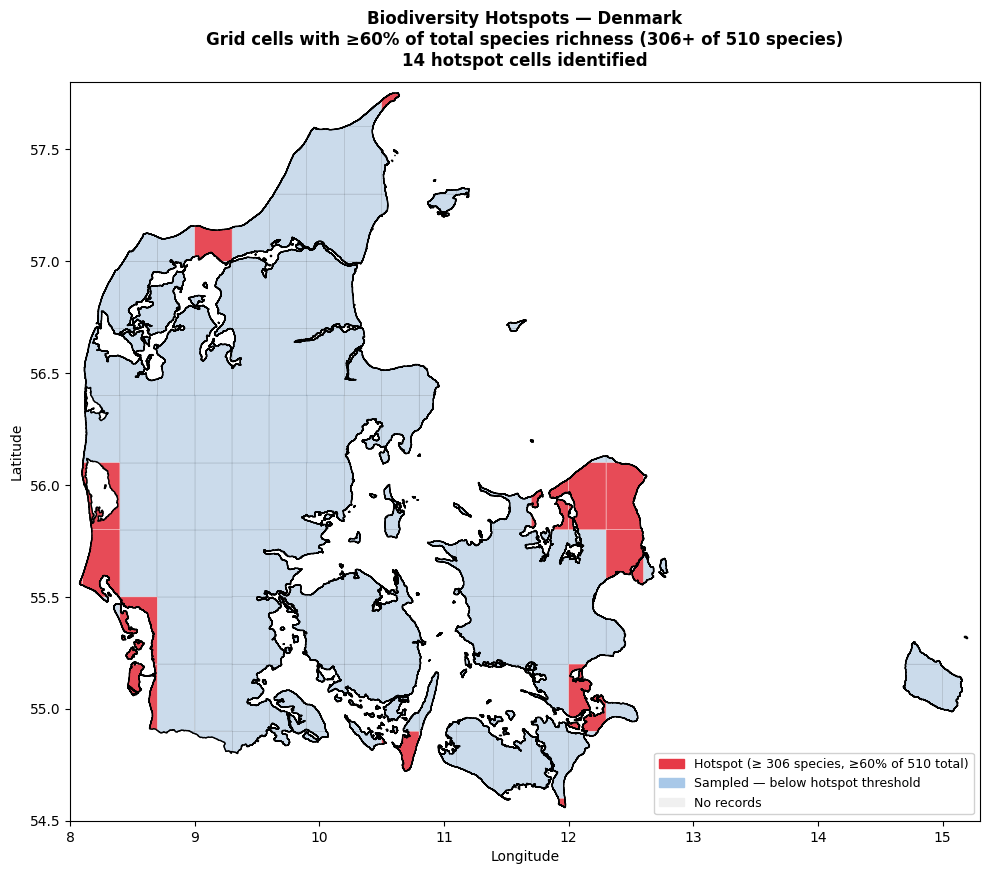

Saved to ../outputs/hotspots_60pct.png


In [8]:
# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))

# Layer 1 — Denmark land background
denmark_outline.plot(
    ax=ax,
    color="#f0f0f0",
    edgecolor="black",
    linewidth=0.8
)

# Layer 2 — Non-hotspot cells with records (light blue, subtle)
# These give context — you can see where sampling happened
# without these dominating the visual
grid_richness[
    (grid_richness["species_richness"] > 0) &
    (~grid_richness["is_hotspot"])
].plot(
    ax=ax,
    color="#a8c8e8",    # muted blue — present but not the focus
    edgecolor="black",
    linewidth=0.1,
    alpha=0.5
)

# Layer 3 — Hotspot cells (bold red — the main finding)
grid_richness[grid_richness["is_hotspot"]].plot(
    ax=ax,
    color="#e63946",    # strong red — visually dominant
    edgecolor="white",
    linewidth=0.3,
    alpha=0.9
)

# Layer 4 — Denmark outline on top so border is always visible
denmark_outline.plot(
    ax=ax,
    color="none",
    edgecolor="black",
    linewidth=1.0
)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(
        color="#e63946",
        label=f"Hotspot (≥ {int(HOTSPOT_THRESHOLD)} species, "
              f"≥60% of {TOTAL_SPECIES} total)"
    ),
    mpatches.Patch(
        color="#a8c8e8",
        label="Sampled — below hotspot threshold"
    ),
    mpatches.Patch(
        color="#f0f0f0",
        edgecolor="black",
        label="No records"
    )
]

ax.legend(
    handles=legend_handles,
    loc="lower right",
    fontsize=9,
    framealpha=0.9
)

# ── Labels and formatting ─────────────────────────────────────────────────────
ax.set_title(
    f"Biodiversity Hotspots — Denmark\n"
    f"Grid cells with ≥60% of total species richness "
    f"({int(HOTSPOT_THRESHOLD)}+ of {TOTAL_SPECIES} species)\n"
    f"{grid_richness['is_hotspot'].sum()} hotspot cells identified",
    fontsize=12, fontweight="bold", pad=12
)

ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude",  fontsize=10)
ax.set_xlim(8.0,  15.3)
ax.set_ylim(54.5, 57.8)

plt.tight_layout()
plt.savefig("../outputs/hotspots_60pct.png", dpi=1600, bbox_inches="tight")
plt.show()

print("Saved to ../outputs/hotspots_60pct.png")